# **imports**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F

from SelfAttention.self_attention import SelfAttention
from SelfAttention.MLP import MLP

from TransformerBlocks.ImageTransformerBlock import ImageTransformerBlock
from TransformerBlocks.PointTransformerBlock import PointTransformerBlock

from UNet import FeatureUNET

# load **DATA**

In [ ]:
def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]

In [ ]:
import random


class PH2ContourDataset(Dataset):
    def __init__(self, base_path, n_punkte=200, img_size=(256, 256)):
        """
        base_path: Der Pfad zum Ordner "PH2 Dataset images" 
                   (z.B. "C:/Users/.../PH2Dataset/PH2 Dataset images")
        """
        self.base_path = base_path
        self.n_punkte = n_punkte
        self.img_size = img_size
        self.samples = []

        # 1. Die exakte Ordnerstruktur des PH2-Datasets auslesen
        for folder_name in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder_name)
            
            # Überprüfen, ob es ein Ordner ist (z.B. "IMD002")
            if os.path.isdir(folder_path):
                # Die Pfade exakt nach der PH2-Namenskonvention zusammenbauen
                img_path = os.path.join(folder_path, f"{folder_name}_Dermoscopic_Image", f"{folder_name}.bmp")
                mask_path = os.path.join(folder_path, f"{folder_name}_lesion", f"{folder_name}_lesion.bmp")
                
                # Nur hinzufügen, wenn beide Dateien auch wirklich existieren
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    self.samples.append({
                        'img_path': img_path,
                        'mask_path': mask_path
                    })

        print(f"Datensatz geladen: {len(self.samples)} Bilder und Masken gefunden.")

        # 2. PyTorch Transformationen für das Konditionierungs-Bild
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- A. BILD VERARBEITEN ---
        img = Image.open(sample['img_path']).convert("RGB")
        mask = Image.open(sample['mask_path']).convert("L") 

        # --- SYNCHRONE AUGMENTATION ---
        
        # 1. Horizontaler Flip (Links/Rechts)
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
            
        # 2. Vertikaler Flip (Oben/Unten)
        if random.random() < 0.5:
            img = TF.vflip(img)
            mask = TF.vflip(mask)

        # 3. Rotation & Zoom (Sicherere Werte!)
        angle = random.uniform(-30, 30) # Vorher -45 bis 45 (oft zu extrem für die Ecken)
        
        # Wir verschieben nur max 10% des Bildes (vorher feste Pixel, was bei kleinen Bildern tödlich ist)
        max_trans_x = int(img.size[0] * 0.1)
        max_trans_y = int(img.size[1] * 0.1)
        translate = (random.randint(-max_trans_x, max_trans_x), random.randint(-max_trans_y, max_trans_y))
        
        # Wir zoomen tendenziell etwas REIN (Scale > 1.0), damit Ränder aus dem Weg gehen.
        # Rauszoomen (Scale < 1.0) bringt oft schwarze Balken an den Rand, auf denen OpenCV hängen bleibt.
        scale = random.uniform(0.95, 1.15) 

        img = TF.affine(img, angle=angle, translate=translate, scale=scale, shear=0)
        mask = TF.affine(mask, angle=angle, translate=translate, scale=scale, shear=0)

        # 4. Farb-Jitter 
        img = transforms.ColorJitter(brightness=0.2, contrast=0.2)(img)

        # --- RESIZE FIX ---
        mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
        img_tensor = self.img_transform(img) 

        mask_np = np.array(mask)
        mask_binary = (mask_np > 0).astype(np.uint8) * 255
        
        # NEU: Wir prüfen den äußersten Pixel-Rand (oben, unten, links, rechts)
        touches_top = np.any(mask_binary[0, :] > 0)
        touches_bottom = np.any(mask_binary[-1, :] > 0)
        touches_left = np.any(mask_binary[:, 0] > 0)
        touches_right = np.any(mask_binary[:, -1] > 0)
        
        # Wenn die Maske den Rand berührt ODER komplett verschwunden ist:
        if touches_top or touches_bottom or touches_left or touches_right or np.sum(mask_binary) == 0:
            # Fallback: Die Augmentation war zu aggressiv! 
            # Wir laden das Originalbild sicherheitshalber OHNE Augmentation neu.
            img = Image.open(sample['img_path']).convert("RGB")
            mask = Image.open(sample['mask_path']).convert("L")
            mask = TF.resize(mask, self.img_size, interpolation=transforms.InterpolationMode.NEAREST)
            img_tensor = self.img_transform(img)
            mask_np = np.array(mask)
            mask_binary = (mask_np > 0).astype(np.uint8) * 255

        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        
        contour = max(contours, key=cv2.contourArea).squeeze()
        points = uniform_sampling(contour, self.n_punkte) 

        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        # ACHTUNG: PyTorch img_size ist (Höhe, Breite). 
        # OpenCV Punkte sind aber (X=Breite, Y=Höhe).
        H, W = self.img_size # Hier richtig entpacken!
        
        points_norm = points.astype(np.float32)
        
        # X-Koordinaten (Breite) normalisieren
        points_norm[:, 0] = points_norm[:, 0] / (W - 1)
        # Y-Koordinaten (Höhe) normalisieren
        points_norm[:, 1] = points_norm[:, 1] / (H - 1)
        
        points_norm = points_norm * 2.0 - 1.0

        points_tensor = torch.tensor(points_norm, dtype=torch.float32)

        return img_tensor, points_tensor

In [ ]:
# 1. Dataset initialisieren


dataset = PH2ContourDataset(base_path="..\PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(288, 384))

# 2. DataLoader erstellen (z.B. 2 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     


In [ ]:
def verify_dataset(batch_images, batch_points, num_samples=4):
    """
    Plottet Bilder und Punkte aus dem PyTorch DataLoader zur Überprüfung.
    batch_images: Tensor der Form (B, 3, H, W) im Bereich [-1, 1]
    batch_points: Tensor der Form (B, n_punkte, 2) im Bereich [-1, 1]
    """
    # Sicherstellen, dass wir nicht mehr Samples plotten, als im Batch sind
    batch_size, channels, H, W = batch_images.shape
    num_samples = min(batch_size, num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    if num_samples == 1:
        axes = [axes] # Fallback, falls nur 1 Bild geplottet wird
        
    for i in range(num_samples):
        # --- 1. BILD DENORMALISIEREN ---
        # Von [-1, 1] zurück auf [0, 1] für Matplotlib
        img = batch_images[i].cpu().numpy()
        # Form ändern von (3, H, W) zu (H, W, 3)
        img = img.transpose(1, 2, 0)
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1) # Sicherheitshalber auf 0-1 abschneiden
        
        # --- 2. PUNKTE DENORMALISIEREN ---
        # Von [-1, 1] zurück auf absolute Pixelkoordinaten
        pts = batch_points[i].cpu().numpy()
        pts_x = (pts[:, 0] + 1.0) / 2.0 * (W - 1)
        pts_y = (pts[:, 1] + 1.0) / 2.0 * (H - 1)
        
        # --- 3. PLOTTEN ---
        axes[i].imshow(img)
        # Punkte als rote Punkte ('r.') und mit Linien verbunden ('-') zeichnen
        axes[i].plot(pts_x, pts_y, 'r.-', markersize=3, linewidth=1)
        
        # Die Kontur optisch schließen (letzten Punkt mit erstem verbinden)
        axes[i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'r-', linewidth=1)
        
        axes[i].axis("off")
        axes[i].set_title(f"Sample {i+1}")
        
    plt.tight_layout()
    plt.show()


In [ ]:

for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  # Wird (16, 3, 576, 766) sein
    print("Punkt-Batch Form:", batch_points.shape) # Wird (16, 200, 2) sein
    
    # Plot aufrufen
    verify_dataset(batch_images, batch_points)
    break # Bricht nach dem ersten Batch ab

In [ ]:
# Teste das neue Feature-U-Net
model = FeatureUNET(in_channels=3, out_features=64)
test_bild = torch.randn(4, 3, 256, 256) # 4 Dummy-Bilder (Batch, RGB, H, W)

wetterkarte = model(test_bild)
print(wetterkarte.shape) 
# Erwartet: torch.Size([4, 64, 256, 256])

# **Diffusion Model**

## Positional Embedding

In [ ]:
import math

class SinusoidalPositionEmbeddings(nn.Module):
    """
    Übersetzt den nackten Zeit-Schritt (z.B. t=500) in einen Vektor,
    den das neuronale Netz verstehen kann. (Standard in Diffusionsmodellen)
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

## **Diffusion Model**

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ContourDiffusionModel(nn.Module):
    def __init__(self, n_punkte=200, context_dim=64, hidden_dim=128, num_layers=4):
        super().__init__()
        self.n_punkte = n_punkte
        
        # 1. Zeit-Einbettung
        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim), 
            nn.GELU(), 
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        # 2. Koordinaten & Features (Die Idee deines Tutors)
        self.coord_mlp = nn.Linear(2, hidden_dim)
        self.feature_mlp = nn.Linear(context_dim, hidden_dim)
        
        # 3. Das 1D-Sequenz-Encoding (Damit die Kette eine Kette bleibt)
        self.seq_embedding = nn.Embedding(n_punkte, hidden_dim)
        
        # 4. Der Point-Transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, dim_feedforward=hidden_dim * 2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.output_mlp = nn.Linear(hidden_dim, 2)

    def forward(self, punkte, zeit, wetterkarte):
        batch_size = punkte.shape[0]
        
        # --- A. Bilineares Sampling (Idee vom Tutor) ---
        grid = punkte.unsqueeze(1) 
        sampled_features = F.grid_sample(wetterkarte, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
        sampled_features = sampled_features.squeeze(2).transpose(1, 2)

        # --- B. Einbettungen berechnen ---
        x_coords = self.coord_mlp(punkte)             
        x_features = self.feature_mlp(sampled_features) 
        
        t = zeit.view(-1, 1).float() / 1000.0 
        t_emb = self.time_mlp(t).unsqueeze(1) 
        
        # 1D-Sequenz-Positionen erzeugen [0, 1, ..., 199]
        seq_idx = torch.arange(self.n_punkte, device=punkte.device).unsqueeze(0).expand(batch_size, -1)
        seq_emb = self.seq_embedding(seq_idx)
        
        # Alles addieren
        x = x_coords + x_features + t_emb + seq_emb
        
        # --- C. Transformer & Output ---
        x = self.transformer(x)
        predicted_noise = self.output_mlp(x)
        
        return predicted_noise

# Test

In [21]:
# 1. Dummy-Daten erzeugen (als kämen sie aus deinem DataLoader)
batch_size = 4
dummy_bilder = torch.randn(batch_size, 3, 576, 768) # 4 Bilder
dummy_punkte = torch.rand(batch_size, 200, 2) * 2 - 1 # 4x 200 Punkte im Bereich [-1, 1]
dummy_zeit = torch.randint(0, 1000, (batch_size,))  # 4 zufällige Zeitschritte

# 2. Modelle initialisieren
unet = FeatureUNET(in_channels=3, out_features=64)
diff_model = ContourDiffusionModel(n_punkte=200, context_dim=64)

# 3. Den Pipeline-Durchlauf testen!
with torch.no_grad():
    # Phase 1: U-Net (Satellit)
    wetterkarte = unet(dummy_bilder)
    print("Shape Wetterkarte:", wetterkarte.shape) # Erwartet: (4, 64, 576, 768)
    
    # Phase 2: Diffusions-Modell
    predicted_noise = diff_model(dummy_punkte, dummy_zeit, wetterkarte)
    print("Shape Predicted Noise:", predicted_noise.shape) # Erwartet: (4, 200, 2)
    
print("BOOM! Die gesamte Architektur steht und ist mathematisch kompatibel!")

Shape Wetterkarte: torch.Size([4, 64, 576, 768])
Shape Predicted Noise: torch.Size([4, 200, 2])
BOOM! Die gesamte Architektur steht und ist mathematisch kompatibel!


In [22]:
import torch

# Standard DDPM Parameter
T = 1000 # 1000 Diffusions-Schritte
# Beta ist die Menge an Rauschen, die pro Schritt addiert wird.
# Es fängt winzig an (0.0001) und wird zum Schluss größer (0.02)
betas = torch.linspace(0.0001, 0.02, T) 

# Alphas definieren, wie viel vom Original-Bild noch übrig ist
alphas = 1.0 - betas
# alphas_cumprod ist die kumulierte Summe. (Gibt an, wie viel Original bei Schritt t noch da ist)
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Helper-Funktion, um den richtigen Alpha-Wert für den Zeitschritt t der Batch auszuwählen
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

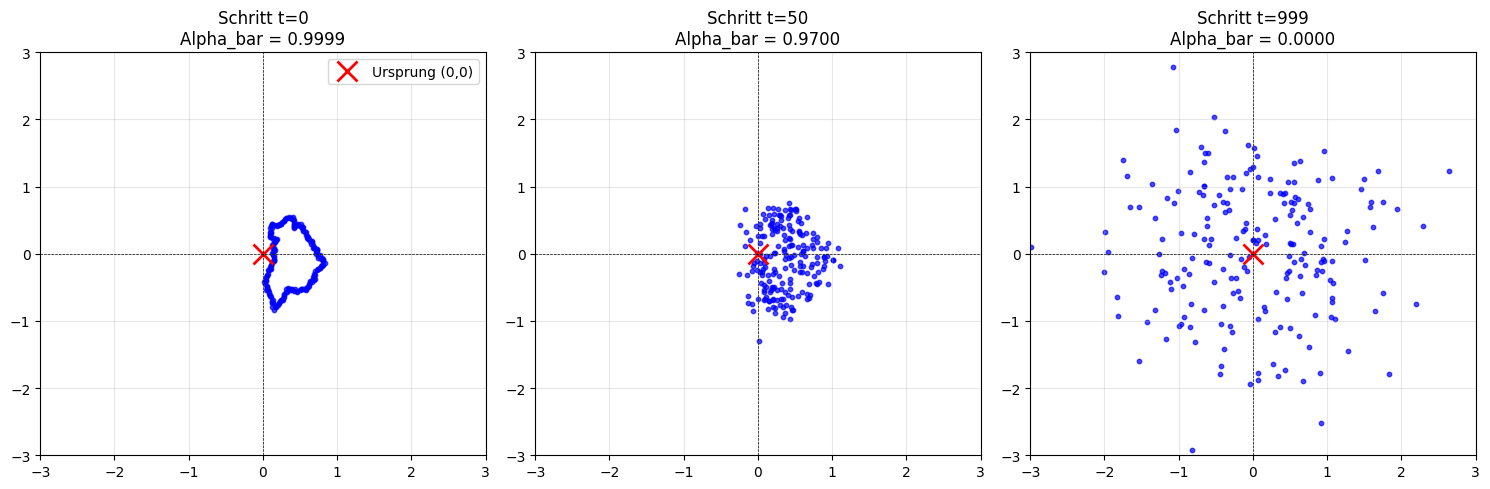

In [23]:
import matplotlib.pyplot as plt
import torch

# 1. Wir holen uns EIN Set an Punkten aus deinem Dataloader
batch_images, batch_points = next(iter(dataloader))
x_0 = batch_points[0] # (200, 2) - Die echten Punkte im Bereich [-1, 1]

# 2. Wir generieren das pure Zufallsrauschen (Gaussian Noise)
# Das ist exakt das, was dein 'noise = torch.randn_like(batch_points)' macht
noise = torch.randn_like(x_0)

# 3. Wir schauen uns drei Zeitpunkte an
zeitpunkte = [0, 50, 999]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, t_val in enumerate(zeitpunkte):
    # Wir holen uns den Skalierungswert für genau diesen Zeitpunkt t
    a_bar = alphas_cumprod[t_val].item()
    
    # DIE MAGISCHE FORMEL (Vorwärts-Diffusion)
    # x_t = (Echter Punkt * restliche Sichtbarkeit) + (Rauschen * aktuelle Rausch-Stärke)
    x_t = (x_0 * (a_bar ** 0.5)) + (noise * ((1 - a_bar) ** 0.5))
    
    # --- PLOTTING ---
    # Wir wandeln die Tensoren in Numpy-Arrays um
    pts = x_t.cpu().numpy()
    
    ax = axes[i]
    # Die Punkte zeichnen (blau)
    ax.scatter(pts[:, 0], pts[:, 1], c='blue', s=10, alpha=0.7)
    
    # Den Ursprung (0, 0) mit einem roten Kreuz markieren
    ax.plot(0, 0, 'rx', markersize=15, markeredgewidth=2, label="Ursprung (0,0)")
    
    # Die Achsen fest auf [-3, 3] setzen, damit wir den Shrink-Effekt sehen!
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"Schritt t={t_val}\nAlpha_bar = {a_bar:.4f}")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [24]:
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt # Für die spätere Auswertung

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Modelle auf die Grafikkarte schieben
unet = FeatureUNET(in_channels=3, out_features=64).to(device)
diff_model = ContourDiffusionModel(n_punkte=200, context_dim=64).to(device)

# WICHTIG: Beide Modelle in EINEN Optimizer packen (End-to-End Training!)
optimizer = optim.AdamW(
    list(unet.parameters()) + list(diff_model.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4
)

EPOCHS = 100 # 100 ~ 1 hour

unet.train()
diff_model.train()

print(f"Starte Training auf {device}...")

scaler = torch.amp.GradScaler('cuda')

# === NEU: Dictionary zum Speichern des Losses ===
training_history = {
    'epoch': [],
    'loss': []
}

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    progress_bar = tqdm(dataloader, desc=f"Epoche {epoch+1}/{EPOCHS}")
    
    for batch_images, batch_points in progress_bar:
        # Daten auf die GPU
        batch_images = batch_images.to(device)
        batch_points = batch_points.to(device) # Das ist unser x_0 (die echten Konturpunkte)
        
        batch_size = batch_images.shape[0]
        optimizer.zero_grad()
        
        # --- SCHRITT 1: Zufällige Zeitpunkte würfeln ---
        t = torch.randint(0, T, (batch_size,), device=device).long()
        
        # --- SCHRITT 2: Reines Rauschen (Epsilon) erzeugen ---
        noise = torch.randn_like(batch_points)
        
        with torch.amp.autocast('cuda'):
            # Rauschen addieren
            sqrt_alphas_cumprod_t = extract(torch.sqrt(alphas_cumprod), t, batch_points.shape)
            sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alphas_cumprod), t, batch_points.shape)
            noisy_points = sqrt_alphas_cumprod_t * batch_points + sqrt_one_minus_alphas_cumprod_t * noise
            
            # Modelle rechnen lassen
            wetterkarte = unet(batch_images)
            predicted_noise = diff_model(noisy_points, t, wetterkarte)
            
            # Loss berechnen
            loss = F.mse_loss(predicted_noise, noise)
        
        # --- SCHRITT 5: Optimieren mit dem Scaler ---
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.5f}"})
        
    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoche {epoch+1} beendet | Avg Loss: {avg_loss:.5f}")
    
    # === NEU: Loss für diese Epoche in das Dictionary eintragen ===
    training_history['epoch'].append(epoch + 1)
    training_history['loss'].append(avg_loss)

Starte Training auf cuda...


Epoche 1/100: 100%|██████████| 100/100 [00:26<00:00,  3.79it/s, Loss=0.12724]


Epoche 1 beendet | Avg Loss: 0.42409


Epoche 2/100: 100%|██████████| 100/100 [00:27<00:00,  3.61it/s, Loss=0.06410]


Epoche 2 beendet | Avg Loss: 0.21171


...

Epoche 98 beendet | Avg Loss: 0.05466


Epoche 99/100: 100%|██████████| 100/100 [00:28<00:00,  3.56it/s, Loss=0.01092]


Epoche 99 beendet | Avg Loss: 0.04241


Epoche 100/100: 100%|██████████| 100/100 [00:28<00:00,  3.54it/s, Loss=0.03322]

Epoche 100 beendet | Avg Loss: 0.04540


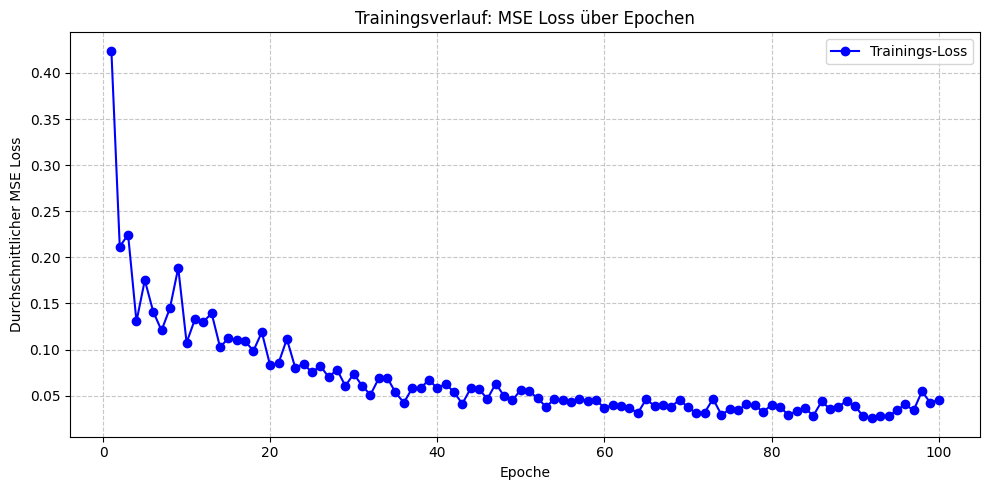

In [25]:
# Die Loss-Kurve plotten
plt.figure(figsize=(10, 5))
plt.plot(training_history['epoch'], training_history['loss'], marker='o', linestyle='-', color='b', label='Trainings-Loss')
plt.title("Trainingsverlauf: MSE Loss über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Durchschnittlicher MSE Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Generiere Kontur (Denoising-Prozess)...


Sampling: 100%|██████████| 1000/1000 [00:06<00:00, 153.71it/s]


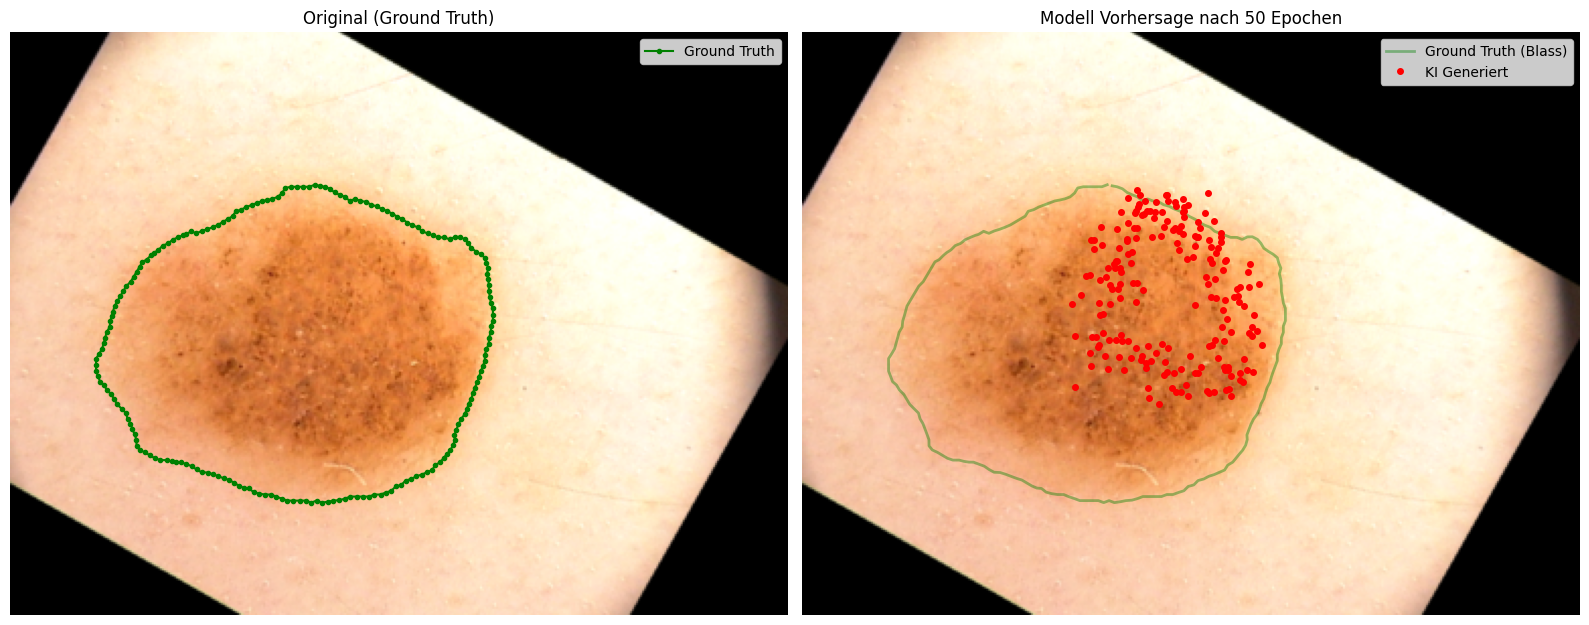

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ==========================================
# 1. AUSWERTUNGS-MODUS AKTIVIEREN
# ==========================================
# Sehr wichtig: Schaltet z.B. Dropout oder BatchNorm-Tracking ab!
unet.eval()
diff_model.eval()

# ==========================================
# 2. DIE SAMPLING-FUNKTION (REVERSE DIFFUSION)
# ==========================================
def sample_contour(unet_model, diffusion_model, image_tensor, T_steps=1000):
    """
    Nimmt ein Bild und lässt das Diffusionsmodell 1000 Schritte lang das Rauschen entfernen,
    um die finale Kontur zu generieren.
    """
    with torch.no_grad(): # Kein Gradienten-Tracking (spart massiv VRAM!)
        # A. U-Net berechnet die Feature-Map ("Wetterkarte") - Das muss nur 1x passieren!
        wetterkarte = unet_model(image_tensor.to(device))
        
        # B. Start-Zustand (t=1000): Eine Wolke aus purem Gauß-Rauschen
        # Form: (1 Batch, 200 Punkte, 2 Koordinaten)
        x = torch.randn(1, 200, 2).to(device)
        
        # C. Der Denoising-Loop (Wir zählen rückwärts von 999 bis 0)
        for t in tqdm(reversed(range(0, T_steps)), desc="Sampling", total=T_steps):
            t_tensor = torch.tensor([t], device=device).long()
            
            # 1. Das Modell rät das aktuelle Rauschen in den Punkten
            with torch.amp.autocast('cuda'):
                predicted_noise = diffusion_model(x, t_tensor, wetterkarte)
            
            # 2. Wir holen uns die physikalischen Konstanten für diesen Zeitschritt
            alpha_t = alphas[t].to(device)
            alpha_t_bar = alphas_cumprod[t].to(device)
            beta_t = betas[t].to(device)
            
            # 3. Langevin Dynamics: Neues Rauschen addieren, ABER nicht im allerletzten Schritt (t=0)
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            # 4. Der magische Denoising-Schritt (Formel aus dem DDPM-Paper)
            term1 = 1 / torch.sqrt(alpha_t)
            term2 = x - ((1 - alpha_t) / torch.sqrt(1 - alpha_t_bar)) * predicted_noise
            term3 = torch.sqrt(beta_t) * noise
            
            x = term1 * term2 + term3
            
    # x enthält am Ende die fertigen Konturpunkte im Bereich [-1, 1]
    return x

# ==========================================
# 3. EIN BILD TESTEN & VISUALISIEREN
# ==========================================
# Wir schnappen uns einfach den ersten Batch aus dem Dataloader
test_images, test_points = next(iter(dataloader))

# Wir nehmen das erste Bild aus diesem Batch
single_image = test_images[0].unsqueeze(0) # Unsqueeze macht aus (3, H, W) ein (1, 3, H, W)
echte_punkte = test_points[0].numpy()

# Lass das Modell die Kontur zeichnen!
print("Generiere Kontur (Denoising-Prozess)...")
generierte_punkte = sample_contour(unet, diff_model, single_image, T_steps=T).cpu().squeeze().numpy()

# --- DATEN FÜR DEN PLOT VORBEREITEN ---

# 1. Bild denormalisieren (von [-1, 1] zurück zu [0, 1] für Matplotlib)
img_vis = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
img_vis = (img_vis * 0.5) + 0.5 
img_vis = np.clip(img_vis, 0, 1)

H, W = img_vis.shape[0], img_vis.shape[1]

# 2. Punkte denormalisieren (von [-1, 1] zurück zu Pixel-Koordinaten)
# (x + 1) / 2 skaliert von [-1, 1] auf [0, 1]. Dann mal (W-1) skaliert auf Pixel.
gen_x = (generierte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
gen_y = (generierte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

echt_x = (echte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
echt_y = (echte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

# --- PLOTTEN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Links: Nur Ground Truth (Grün)
axes[0].imshow(img_vis)
axes[0].plot(echt_x, echt_y, 'g.-', markersize=6, linewidth=1.5, label="Ground Truth")
axes[0].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5) # Ring schließen
axes[0].set_title("Original (Ground Truth)")
axes[0].legend()
axes[0].axis("off")

# Rechts: Ground Truth + Modell-Vorhersage (Rot)
axes[1].imshow(img_vis)
axes[1].plot(echt_x, echt_y, 'g-', alpha=0.4, linewidth=2, label="Ground Truth (Blass)")
# ACHTUNG: Wir zeichnen aktuell NUR die roten Punkte (keine Verbindungslinien), 
# um das "Knäuel-Problem" visuell besser beurteilen zu können!
axes[1].plot(gen_x, gen_y, 'r.', markersize=8, label="KI Generiert")
axes[1].set_title("Modell Vorhersage nach 50 Epochen")
axes[1].legend()
axes[1].axis("off")

plt.tight_layout()
plt.show()